In [1]:
# --- Colab bootstrap -------------------------------------------------------
import os, sys
if not (os.path.isdir('../thermo') or os.path.isdir('thermo')):
    !rm -rf /tmp/cbet6e
    !git clone -q --depth 1 https://github.com/emfurst/cbet6e.git /tmp/cbet6e
    !cp -r /tmp/cbet6e/code/thermo /tmp/cbet6e/code/data .
    sys.path.insert(0, '.')
# ---------------------------------------------------------------------------

# Pressure-swing distillation of an azeotrope (methyl acetate / methanol)

This notebook backs **Illustrations 10.2-2 and 10.2-3** and **Figures 10.2-2 and 10.2-3** —
the constant-temperature and constant-pressure diagrams for methyl acetate / methanol, the
bubble and dew points read from them, and the two-column pressure-swing design that
separates the azeotrope. They are one calculation, so they are one notebook.

This is Section 10.1's procedure with $\gamma \ne 1$, and the machinery is unchanged:
`GammaPhi` takes an activity coefficient model instead of `Ideal()` and everything else is
the same call. What changes is the *shape* of the answer — the equilibrium pressure is no
longer linear in composition, and the system forms an **azeotrope**.

**Why this system and not the 5e's.** The 5e worked this material on ethyl acetate /
benzene, whose azeotrope is not real: standard azeotrope compilations do not list one, and
it is an artifact of Table 9.5-1's van Laar constants for that pair, which imply
infinite-dilution activity coefficients of 3.16 and 2.51 for two species boiling three
degrees apart. UNIFAC, predicting from structure alone, gives activity coefficients within a
few percent of one and no azeotrope. That disagreement is now the subject of Problem
10.2-72 — the student does the disproving — and the worked example moved to methyl acetate /
methanol, a real and well-documented minimum-boiling azeotrope that Table 9.5-1 already
carries.

**Two consequences of the change, and neither is cosmetic:**

- The azeotropic composition moves the *opposite way* with pressure in the two systems, so
  the second column runs at **higher** pressure, not lower. A low-pressure second column
  cannot work for this mixture at any pressure.
- The 5e labels column 2's two products the wrong way round. For a minimum-boiling
  azeotrope the distillate is driven toward the azeotrope and the bottoms toward the pure
  component; the 5e has the high-purity stream as the distillate. That is erratum E17, and
  it applied to the printed figure whatever system was used.

SIS is Stanley I. Sandler, *Chemical, Biochemical, and Engineering Thermodynamics*.

Eric Furst  
August 2026

In [2]:
import sys; sys.path.append("..")
import numpy as np
import matplotlib.pyplot as plt
from thermo.vle import Antoine, psat_from_database, GammaPhi, pxy, txy, azeotrope
from thermo.vle_chart import pxy_chart, txy_chart, xy_chart, total_reflux_steps
from thermo.activity_models import VanLaar, TABLE_9_5_1_VAN_LAAR
from thermo.charts import use_book_style
use_book_style()

# Antoine constants, ln P(bar) = A - B/(T(K) + C), printed in the illustration's Data
# block so the calculation is reproducible by hand. They are FITTED to the reference
# (Wagner) correlation in code/data/pure_property.csv over 40-100 C, which spans both
# columns; the fit is within 0.04 % across that window. The 5e prints Antoine constants
# for its own pair in exactly this form, and for the same reason.
MA = Antoine(9.5037, 2589.1, -57.2787)      # methyl acetate
ME = Antoine(11.8957, 3586.2, -35.8366)     # methanol

# and the check that they may be used in place of the reference correlation
for nm, fitted in (("methyl acetate", MA), ("methanol", ME)):
    ref = psat_from_database(nm)
    e = max(abs(fitted.P(T)/ref.P(T) - 1) for T in np.linspace(313.15, 373.15, 200))
    print(f"  {nm:15s} Antoine vs reference correlation, 40-100 C: max {100*e:.3f} %")
alpha, beta, rng = TABLE_9_5_1_VAN_LAAR["methyl acetate-methanol"]
mix = GammaPhi([MA, ME], VanLaar(alpha, beta), names=["methyl acetate", "methanol"])
print(f"\nTable 9.5-1: alpha = {alpha}, beta = {beta}, fitted over {rng} C")
print(f"normal boiling points: methyl acetate {MA.T_sat(1.01325e5)-273.15:.1f} C, "
      f"methanol {ME.T_sat(1.01325e5)-273.15:.1f} C")

  methyl acetate  Antoine vs reference correlation, 40-100 C: max 0.016 %
  methanol        Antoine vs reference correlation, 40-100 C: max 0.035 %

Table 9.5-1: alpha = 1.06, beta = 1.06, fitted over 53.7-64.6 C
normal boiling points: methyl acetate 56.9 C, methanol 64.5 C


## The azeotrope is real, and the constants find it

The check that licensed the whole example: Table 9.5-1's own constants, with no tuning,
against the reported azeotrope.

In [3]:
P1, P2 = 1.013e5, 3.0e5
az1, az2 = azeotrope(mix, P=P1), azeotrope(mix, P=P2)
print(f"computed at 1.013 bar:  x = {az1[0]:.4f} methyl acetate, T = {az1[1]-273.15:.2f} C")
print(f"reported:               x = 0.654,  T = 53.5 C")
print(f"\nat 3 bar (column 2):    x = {az2[0]:.4f}, T = {az2[1]-273.15:.2f} C")

computed at 1.013 bar:  x = 0.6552 methyl acetate, T = 53.35 C
reported:               x = 0.654,  T = 53.5 C

at 3 bar (column 2):    x = 0.5613, T = 84.87 C


## The pressure swing runs the other way

This is the fact that decides the design, and it is opposite to the 5e's system.

In [4]:
print("   P (bar)   x_az (methyl acetate)   T (C)     within the 53.7-64.6 C fit range?")
for P in (0.1013e5, 0.5e5, 1.013e5, 3e5, 6e5):
    a = azeotrope(mix, P=P)
    Tc_ = a[1] - 273.15
    print(f"   {P/1e5:7.4f}   {a[0]:.3f}                  {Tc_:6.2f}    "
          f"{'yes' if 53.7 <= Tc_ <= 64.6 else 'no'}")
print("\nLowering the pressure RAISES x_az, moving the azeotrope away from the feed.")
print("So the second column must run ABOVE the first, not below.")

   P (bar)   x_az (methyl acetate)   T (C)     within the 53.7-64.6 C fit range?
    0.1013   0.831                    3.10    no
    0.5000   0.713                   35.88    no
    1.0130   0.655                   53.35    no
    3.0000   0.561                   84.87    no
    6.0000   0.498                  108.62    no

Lowering the pressure RAISES x_az, moving the azeotrope away from the feed.
So the second column must run ABOVE the first, not below.


### Why that forces the direction

A minimum-boiling azeotrope is the most volatile condition the mixture can reach. Whatever
the feed, the distillate is driven toward the azeotropic composition and the bottoms toward
whichever pure component lies on the feed's side of it.

Column 1 takes a feed below the 1.013 bar azeotrope, so its bottoms is methanol and its
distillate is the azeotrope, 0.655. For column 2 to make further progress, its own
azeotrope must lie **below** 0.655 — otherwise the feed sits on the methanol side again and
the column simply produces more methanol. Only a higher pressure achieves that.

In [5]:
zF, xB1, xD2 = 0.40, 0.05, 0.95
for P in (0.1013e5, 0.5e5, 3e5, 6e5):
    a = azeotrope(mix, P=P)[0]
    side = "above" if az1[0] > a else "below"
    ok = "pure methyl acetate" if az1[0] > a else "pure methanol AGAIN -- fails"
    print(f"   column 2 at {P/1e5:6.3f} bar: x_az = {a:.3f}, feed {az1[0]:.3f} is {side}"
          f"  ->  bottoms = {ok}")

   column 2 at  0.101 bar: x_az = 0.831, feed 0.655 is below  ->  bottoms = pure methanol AGAIN -- fails
   column 2 at  0.500 bar: x_az = 0.713, feed 0.655 is below  ->  bottoms = pure methanol AGAIN -- fails
   column 2 at  3.000 bar: x_az = 0.561, feed 0.655 is above  ->  bottoms = pure methyl acetate
   column 2 at  6.000 bar: x_az = 0.498, feed 0.655 is above  ->  bottoms = pure methyl acetate


## Illustration 10.2-2 — the two diagram pairs

Pvap at 60 C: methyl acetate 1.1258 bar, methanol 0.8468 bar
azeotrope at 60 C: x = 0.6344, P = 1.2972 bar


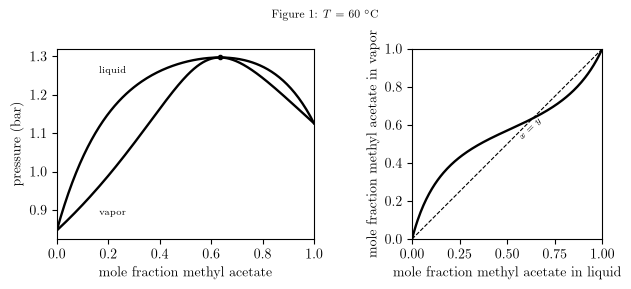

In [6]:
T_iso = 273.15 + 60.0
print(f"Pvap at 60 C: methyl acetate {MA.P(T_iso)/1e5:.4f} bar, methanol {ME.P(T_iso)/1e5:.4f} bar")
azT = azeotrope(mix, T=T_iso)
print(f"azeotrope at 60 C: x = {azT[0]:.4f}, P = {azT[1]/1e5:.4f} bar")

xi, yi, Pi = pxy(mix, T_iso)
xb, yb, Tb = txy(mix, P1)

fig, (a1, a2) = plt.subplots(1, 2, figsize=(6.6, 2.9))
pxy_chart(a1, xi, yi, Pi, species="methyl acetate", regions=False,
          curve_labels=("liquid", "vapor"))
a1.plot([azT[0]], [azT[1]/1e5], "o", color="k", ms=3)
xy_chart(a2, xi, yi, species="methyl acetate")
fig.suptitle(r"Figure 1: $T$ = 60 $^\circ$C", fontsize=8); fig.tight_layout()

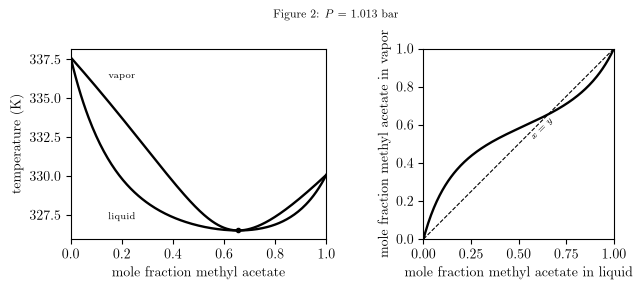

In [7]:
fig, (b1, b2) = plt.subplots(1, 2, figsize=(6.6, 2.9))
txy_chart(b1, xb, yb, Tb, species="methyl acetate", regions=False,
          curve_labels=("liquid", "vapor"))
b1.plot([az1[0]], [az1[1]], "o", color="k", ms=3)
xy_chart(b2, xb, yb, species="methyl acetate")
fig.suptitle("Figure 2: $P$ = 1.013 bar", fontsize=8); fig.tight_layout()

## Illustration 10.2-3 — bubble and dew points from the same model

In [8]:
z = [0.20, 0.80]
Pb_, yb_ = mix.bubble_pressure(z, T_iso); Pd_, xd_ = mix.dew_pressure(z, T_iso)
Tb_, yt_ = mix.bubble_temperature(z, P1); Td_, xt_ = mix.dew_temperature(z, P1)
print("20 mol % methyl acetate")
print(f"  at 60 C      bubble {Pb_/1e5:.4f} bar (y = {yb_[0]:.4f}),"
      f"  dew {Pd_/1e5:.4f} bar (x = {xd_[0]:.4f})")
print(f"  at 1.013 bar bubble {Tb_:.2f} K (y = {yt_[0]:.4f}),"
      f"  dew {Td_:.2f} K (x = {xt_[0]:.4f})")

20 mol % methyl acetate
  at 60 C      bubble 1.1505 bar (y = 0.3857),  dew 0.9892 bar (x = 0.0703)
  at 1.013 bar bubble 329.84 K (y = 0.3909),  dew 333.74 K (x = 0.0706)


## Figures 10.2-2 and 10.2-3 — the two columns at total reflux

Each column is stepped off **from its own feed**, in both directions, because that is what the
design claims and each direction is a different recursion:

- **down toward the reboiler**, $x_{n+1} = f^{-1}(x_n)$, which moves *away* from the azeotrope
  toward the pure component on the feed's side of it. This branch reaches the 95 % product
  specification in a finite number of stages; as in Illustration 10.1-6, the last stage steps
  *past* the specification and is still counted.

**The bottoms line marks where the staircase lands, not the specification.** At total reflux
an integer number of stages cannot meet a spec exactly — three stages take column 1 to 0.022
where two would leave it at 0.075 — so a line drawn at the spec floats between two corners and
reads as a misalignment. Drawing it at the achieved composition puts it on the staircase, and
the label names the specification that composition satisfies.
- **up toward the condenser**, $x_{n+1} = f(x_n)$, which moves *toward* the azeotrope. This
  branch **pinches**: the steps shrink geometrically against the azeotropic composition and
  never pass it. That is the constraint the whole two-column design exists to defeat, so the
  figure has to show it rather than assert it.

Which direction is which comes out of the arithmetic — `total_reflux_steps` applies the
equilibrium curve or its inverse rather than assuming the plotted species is the volatile one.
That is what makes **both products leave as bottoms** a computed result rather than a habit,
and getting it backwards is erratum E17 in the 5e.

**A stage count is only meaningful between two stated compositions.** Neither column can be
counted from its distillate, because the distillate *is* the azeotrope and the steps there are
infinitesimal; counts below are feed → product, which is what the design specifies.

**Every corner of a staircase must land on the equilibrium curve**, in both directions —
which is to say the steps never cross the $x = y$ diagonal. Ascending, the corner is $(x_n,
f(x_n))$: up to the curve, then across to the diagonal. Descending it is $(f^{-1}(x_n), x_n)$:
across to the curve, then down. Using one order for both reflects the staircase in the
diagonal, and `total_reflux_steps` now has a doctest that checks the invariant.

stages at total reflux, feed -> product:
   column 1  0.400 -> 0.022  (97.8% methanol, spec 95%)       3 stages
   column 2  0.655 -> 0.962  (96.2% methyl acetate, spec 95%)  4 stages

and in the other direction, toward the condenser:
   column 1  11 steps and pinched at the azeotrope: True
   column 2  9 steps and pinched at the azeotrope: True


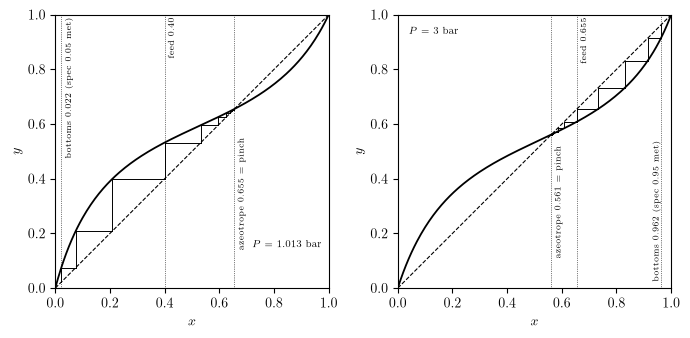

In [9]:
def column(ax, xs, ys, x_feed, x_spec, x_az, P_label, marks, p_pos=(0.04, 0.93),
           bottoms_y=0.99):
    """One column at total reflux, stepped from the feed in both directions.

    The bottoms line is drawn WHERE THE STAIRCASE LANDS, not at the specification.
    At total reflux an integer number of stages cannot hit a spec exactly -- the last
    stage always overshoots -- so a line drawn at the spec floats between two corners
    and reads as a misalignment (author, 2026-08-14). Marking the achieved composition
    puts the line on the staircase, keeps every corner on the equilibrium curve, and
    the label still names the specification that composition satisfies.

    `marks` is (x, label, y_label) for the feed and azeotrope lines; the label heights
    are hand-placed, because the staircase and the curve leave different gaps in the
    two figures.
    """
    ax.plot([0, 1], [0, 1], "--", color="k", lw=0.8)
    ax.plot(xs, ys, "-", color="k", lw=1.3)
    # clip=False: the last stage is a whole stage and steps past the specification,
    # which is what Illustration 10.1-6 describes in words and the only construction
    # that keeps every corner of the staircase on the equilibrium curve.
    n_dn, segs, _ = total_reflux_steps(ax, xs, ys, x_feed, x_spec, direction="down",
                                       clip=False)
    n_up, _, pinched = total_reflux_steps(ax, xs, ys, x_feed, direction="up")
    x_bot = segs[-1][2]                      # where the staircase actually ends
    for xv, lab, ylab in list(marks) + [
            (x_bot, f"bottoms {x_bot:.3f} (spec {x_spec:.2f} met)", bottoms_y)]:
        ax.axvline(xv, color="k", lw=0.5, ls=":")
        dx = 0.014 if xv < 0.88 else -0.030   # keep a right-hand label inside the frame
        t = ax.text(xv + dx, ylab, lab, fontsize=5.6, rotation=90, va="top")
        # A rotated label is as long as its text, so a start height that suits one
        # figure runs off the bottom of another. Measure it and lift it if it would
        # cross the axis, rather than hand-tuning a number per label.
        ax.figure.canvas.draw()
        bb = t.get_window_extent().transformed(ax.transAxes.inverted())
        if bb.y0 < 0.02:
            t.set_y(ylab + (0.02 - bb.y0))
    ax.text(*p_pos, P_label, fontsize=7)
    ax.set_xlabel("$x$"); ax.set_ylabel("$y$")
    ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.set_aspect("equal", adjustable="box")
    return n_dn, n_up, pinched, x_bot

x2, y2, T2 = txy(mix, P2)
fig, (c1, c2) = plt.subplots(1, 2, figsize=(7.0, 3.5))
n1, u1, p1_, b1 = column(c1, xb, yb, zF, xB1, az1[0], "$P$ = 1.013 bar",
                         [(zF, "feed 0.40", 0.99),
                          (az1[0], "azeotrope 0.655 = pinch", 0.55)],
                         p_pos=(0.72, 0.15))
n2, u2, p2_, b2 = column(c2, x2, y2, az1[0], xD2, az2[0], "$P$ = 3 bar",
                         [(az2[0], "azeotrope 0.561 = pinch", 0.52),
                          (az1[0], "feed 0.655", 0.99)],
                         bottoms_y=0.45)
fig.tight_layout()
print("stages at total reflux, feed -> product:")
print(f"   column 1  {zF:.3f} -> {b1:.3f}  ({100*(1-b1):.1f}% methanol,"
      f" spec {100*(1-xB1):.0f}%)       {n1} stages")
print(f"   column 2  {az1[0]:.3f} -> {b2:.3f}  ({100*b2:.1f}% methyl acetate,"
      f" spec {100*xD2:.0f}%)  {n2} stages")
print("\nand in the other direction, toward the condenser:")
print(f"   column 1  {u1} steps and pinched at the azeotrope: {p1_}")
print(f"   column 2  {u2} steps and pinched at the azeotrope: {p2_}")

Read the two panels together and the design reads off them:

**Both products leave as bottoms.** In each column the staircase running *down* from the feed
reaches a 95 % product in a handful of stages — three stages to 97.8 % methanol in column 1,
four to 96.2 % methyl acetate in column 2, both comfortably past the specification — while the
staircase running *up* piles against the azeotrope and stops. So each column's
overhead is the azeotrope of *its own* pressure, and column 2's overhead, at the 3 bar
azeotropic composition, is the recycle to column 1. That is the correction described at the
top; the 5e has these swapped for column 2.

**What the pressure swing buys** is visible as the gap between the two dotted azeotrope lines:
0.655 at 1.013 bar and 0.561 at 3 bar. Column 1's overhead is stuck at 0.655, but at 3 bar that
same stream sits *above* the azeotrope, on the methyl-acetate-rich side, where the volatility
order has reversed — so column 2 strips it downward to pure methyl acetate. Neither column can
cross its own azeotrope; the pair can, because the azeotrope moves.

**The two stage counts are close, and the earlier claim that column 1 needs far more stages
was an artifact.** That count was made by starting the staircase *at* the azeotrope, which is a
fixed point of the recursion: the first eleven steps moved the composition by less than 0.001
and the "22 stages" were mostly the arithmetic crawling out of a pinch. Counted from the feed,
as specified, it is three stages against column 2's four. It is also why that count once
flipped from 21 to 22 on a change in the fourth decimal of a vapor-pressure constant — a stage
count that sensitive is not measuring the chemistry.

## Print art

In [10]:
# --- Print art -------------------------------------------------------------
# pdf/ is what production takes. png/ is for review and for the supplement draft
# that carried these figures inline; c10.docx itself uses `Insert figure ... here`
# placeholders and embeds no images, so there is nothing there to drift.
#
#   pdf/Illustration_10.2-2_fig1.pdf -> print-bw/ch10/c10uf004.pdf   P-x-y + x-y, 60 C
#   pdf/Illustration_10.2-2_fig2.pdf -> print-bw/ch10/c10uf005.pdf   T-x-y + x-y, 1.013 bar
#   pdf/Fig_10.2-2.pdf               -> print-bw/ch10/c10f014.pdf    column 1, 1.013 bar
#   pdf/Fig_10.2-3.pdf               -> print-bw/ch10/c10f015.pdf    column 2, 3 bar
#
# No region labels on the envelopes: on a minimum-boiling azeotrope the frame edge sits
# just past the azeotropic point, so the single-phase regions are thin bands with no
# room. The 5e art omits them here for the same reason.
#
# The two LINES are named instead (author's request, 2026-08-15). On these diagrams the
# usual cue for telling them apart fails: liquid is the upper curve on a P-x-y and the
# lower one on a T-x-y, but BOTH swap sides across the azeotrope, so an unlabeled
# envelope leaves the reader nothing to go on. `curve_labels` writes each name beside
# its own curve where the two are furthest apart.
import os
os.makedirs("pdf", exist_ok=True); os.makedirs("png", exist_ok=True)

def save(fig, stem, dpi_png):
    fig.savefig(f"pdf/{stem}.pdf", dpi=300, bbox_inches="tight")
    fig.savefig(f"png/{stem}.png", dpi=dpi_png, bbox_inches="tight")
    plt.close(fig)

f, (a, b) = plt.subplots(1, 2, figsize=(6.6, 2.9))
pxy_chart(a, xi, yi, Pi, species="methyl acetate", regions=False,
          curve_labels=("liquid", "vapor"))
a.plot([azT[0]], [azT[1]/1e5], "o", color="k", ms=3)
xy_chart(b, xi, yi, species="methyl acetate"); f.tight_layout()
save(f, "Illustration_10.2-2_fig1", 200)

f, (a, b) = plt.subplots(1, 2, figsize=(6.6, 2.9))
txy_chart(a, xb, yb, Tb, species="methyl acetate", regions=False,
          curve_labels=("liquid", "vapor"))
a.plot([az1[0]], [az1[1]], "o", color="k", ms=3)
xy_chart(b, xb, yb, species="methyl acetate"); f.tight_layout()
save(f, "Illustration_10.2-2_fig2", 200)

# Single panels for print, same construction as above: stepped from the feed, down to
# the product spec and up into the pinch. The label heights differ from the two-panel
# display version because a single panel is wider on the page.
f, a = plt.subplots(figsize=(3.5, 3.5))
column(a, xb, yb, zF, xB1, az1[0], "$P$ = 1.013 bar",
       [(zF, "feed 0.40", 0.99), (az1[0], "azeotrope 0.655 = pinch", 0.55)],
       p_pos=(0.72, 0.15))
f.tight_layout(); save(f, "Fig_10.2-2", 260)

f, a = plt.subplots(figsize=(3.5, 3.5))
column(a, x2, y2, az1[0], xD2, az2[0], "$P$ = 3 bar",
       [(az2[0], "azeotrope 0.561 = pinch", 0.52), (az1[0], "feed 0.655", 0.99)],
       bottoms_y=0.45)
f.tight_layout(); save(f, "Fig_10.2-3", 260)
print("wrote 4 figures to pdf/ and png/")

wrote 4 figures to pdf/ and png/


## Your turn

1. The second column was placed at 3 bar, the smallest pressure that works. Sweep it from
   2 to 10 bar and plot the number of stages and the recycle flow against pressure. Where
   would you put it, and what does the answer cost in extrapolating Table 9.5-1's constants
   beyond their 53.7–64.6 °C range?
2. Step column 1 *up* from the feed one stage at a time and tabulate how far each step moves
   the composition. How many stages would it take to get within 0.001 of the azeotrope, and
   what does your answer say about quoting a stage count for a column whose distillate is an
   azeotrope?
3. The recycle is column 2's overhead, at the 3 bar azeotropic composition, and it returns to
   column 1's feed. Write the two mass balances and find the recycle flow per mole of fresh
   feed. What happens to it as column 2's pressure approaches the pressure at which the
   azeotrope reaches the feed composition?
4. Problem 10.2-72 asks whether ethyl acetate / benzene has an azeotrope. Answer it with
   **UNIFAC**, then try to run this same two-column design on whatever answer you get. What
   does the attempt tell you about designing a separation on a correlation you have not
   checked?